# NAVYA — Feature Engineering

This notebook builds precisely the 18 numerical features accepted by the mobile-app contract. `woman_id` remains only a grouping field and is never part of `X`.

## 1. Load cleaned data and declare the immutable feature contract

The ordered list is both displayed and saved with the model-ready data so training and inference cannot silently change column order.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().resolve()
ROOT = ROOT if (ROOT / "data").exists() else ROOT.parent
clean = pd.read_csv(ROOT / "processed_data" / "cleaned_dataset.csv")
FEATURES = [
    "age_years",
    "menarche_age",
    "height_cm",
    "weight_kg",
    "bmi",
    "sleep_hours",
    "stress_level",
    "exercise_frequency",
    "uses_medication_or_contraceptive",
    "prev_cycle_1",
    "prev_cycle_2",
    "prev_cycle_3",
    "avg_previous_cycle_length",
    "std_previous_cycle_length",
    "prev_period_1",
    "prev_period_2",
    "prev_period_3",
    "avg_previous_period_length",
]
print("Feature count:", len(FEATURES))
display(pd.DataFrame({"position": range(1, 19), "feature": FEATURES}))

Feature count: 18


,position,feature
0,1,age_years
1,2,menarche_age
2,3,height_cm
3,4,weight_kg
4,5,bmi
5,6,sleep_hours
6,7,stress_level
7,8,exercise_frequency
8,9,uses_medication_or_contraceptive
9,10,prev_cycle_1


## 2. Create history and derived features

The averages are row means of the three histories. The cycle standard deviation uses `ddof=0`, the requested population standard deviation.

In [3]:
df = clean.copy()
df = df.rename(
    columns={
        "prev1_cycle_length": "prev_cycle_1",
        "prev2_cycle_length": "prev_cycle_2",
        "prev3_cycle_length": "prev_cycle_3",
        "prev1_period_length": "prev_period_1",
        "prev2_period_length": "prev_period_2",
        "prev3_period_length": "prev_period_3",
    }
)
cycle_cols = ["prev_cycle_1", "prev_cycle_2", "prev_cycle_3"]
period_cols = ["prev_period_1", "prev_period_2", "prev_period_3"]
df["avg_previous_cycle_length"] = df[cycle_cols].mean(axis=1)
df["std_previous_cycle_length"] = df[cycle_cols].std(axis=1, ddof=0)
df["avg_previous_period_length"] = df[period_cols].mean(axis=1)
assert df["woman_id"].notna().all()
assert all(c in df.columns for c in FEATURES + ["next_cycle_length_days"])
assert "woman_id" not in FEATURES and "next_cycle_length_days" not in FEATURES

## 3. Validate generated features and inspect relationships

This verifies formulas on sample rows, reports missingness, and visualizes feature-target correlations and feature distributions. It is a leakage check: all features are present-time demographics or previous-history fields only.

,prev_cycle_1,prev_cycle_2,prev_cycle_3,avg_previous_cycle_length,std_previous_cycle_length
10650,23,28,25,25.333333,2.054805
2041,31,29,32,30.666667,1.247219
8668,34,32,32,32.666667,0.942809
1114,32,32,32,32.000000,0.000000
13902,27,28,26,27.000000,0.816497


,missing
age_years,0
menarche_age,0
height_cm,0
weight_kg,0
bmi,0
sleep_hours,0
stress_level,0
exercise_frequency,0
uses_medication_or_contraceptive,580
prev_cycle_1,0


,correlation_with_target
sleep_hours,-0.159238
exercise_frequency,-0.062575
bmi,-0.035078
age_years,-0.012857
weight_kg,-0.010876
std_previous_cycle_length,-0.006115
uses_medication_or_contraceptive,-0.003756
prev_period_3,0.010469
menarche_age,0.010793
prev_period_2,0.011786


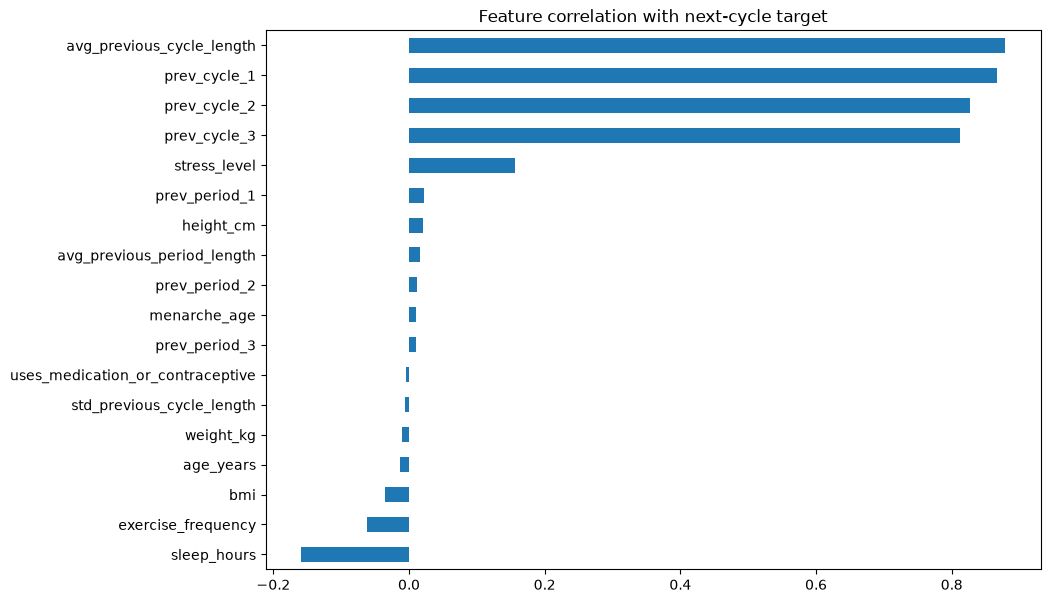

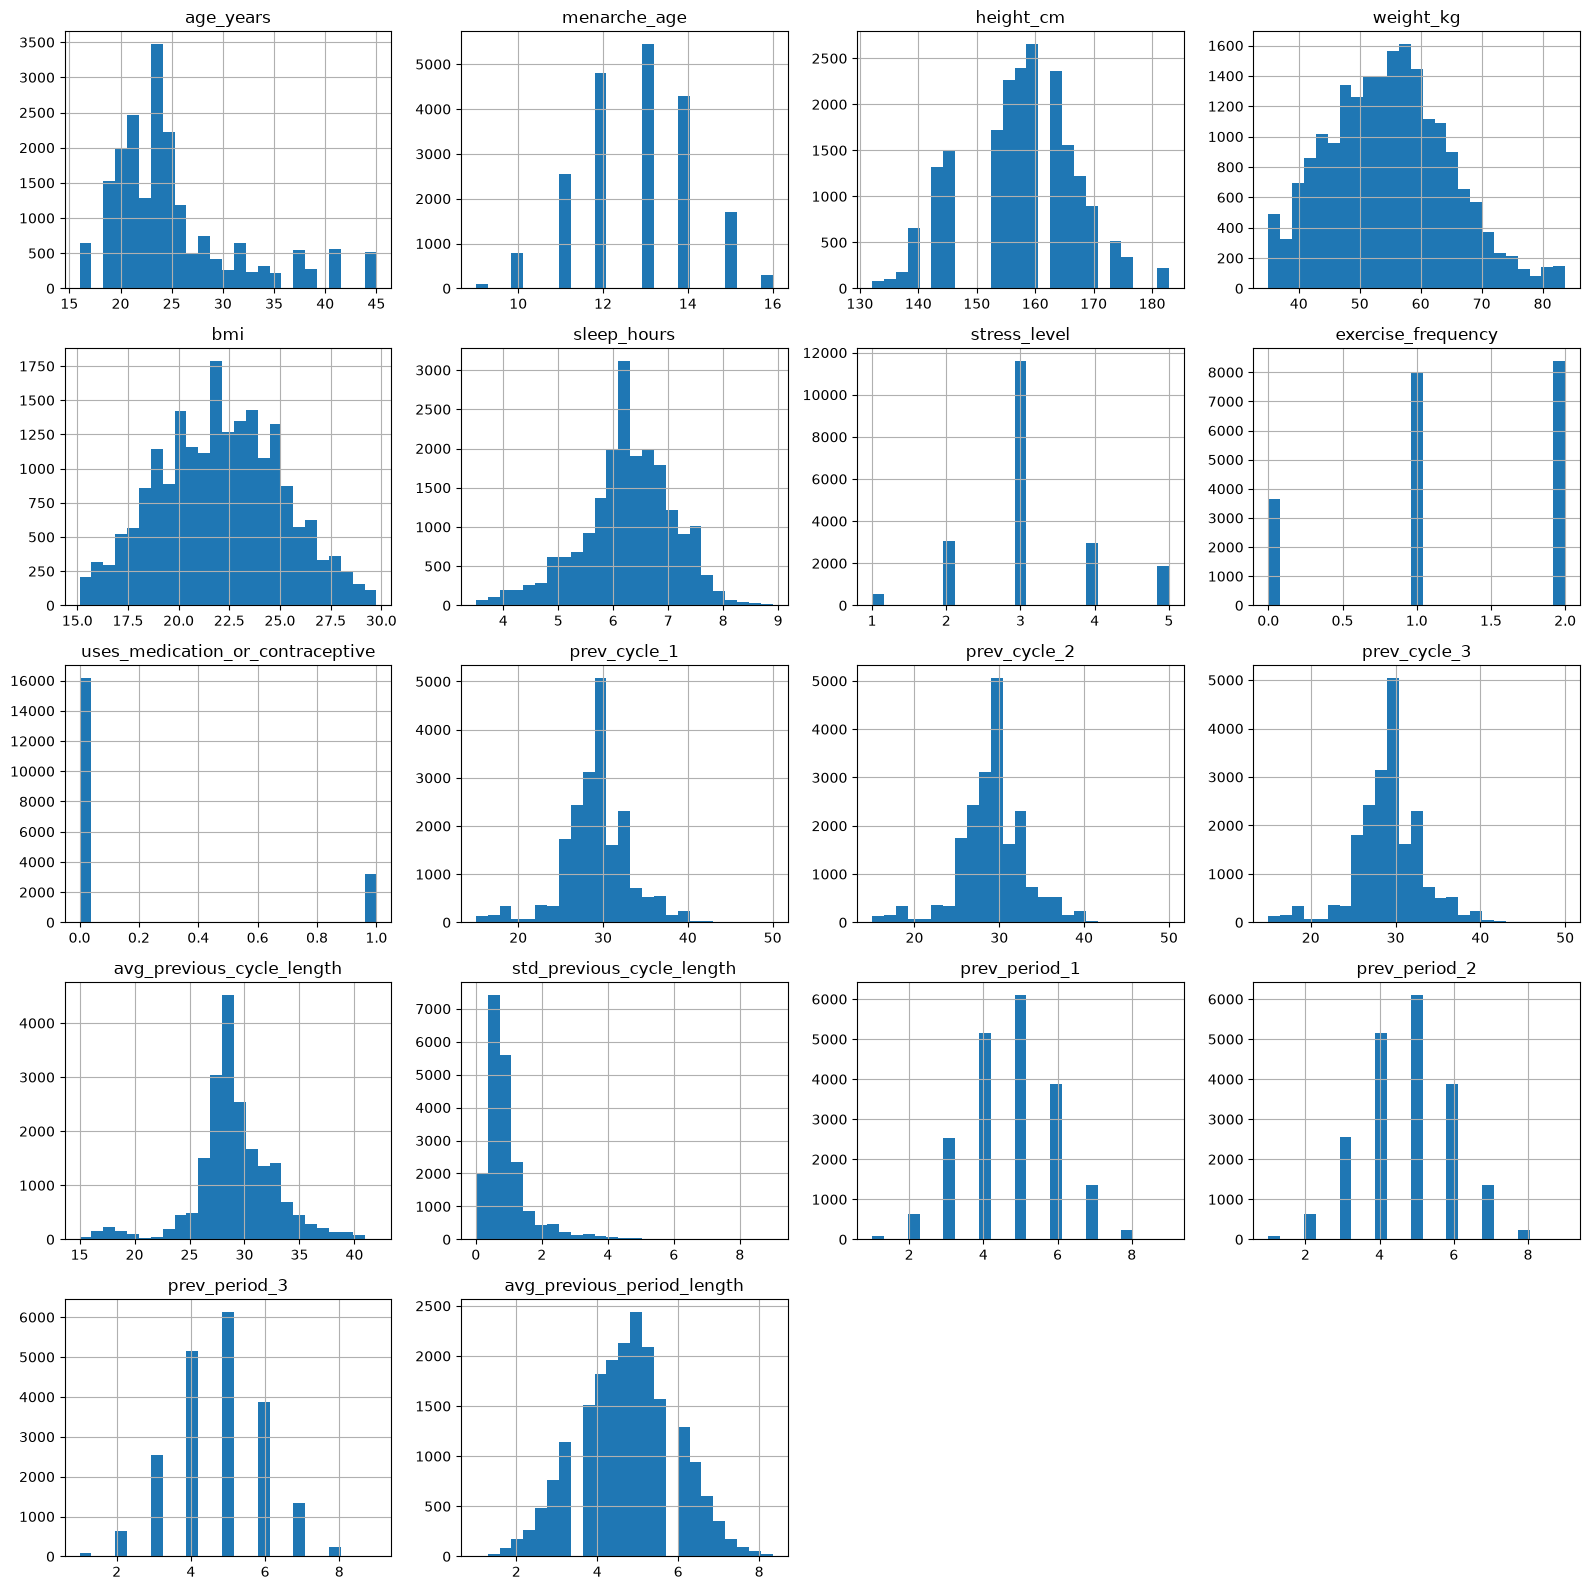

In [4]:
sample = df.sample(min(5, len(df)), random_state=42)
display(sample[cycle_cols + ["avg_previous_cycle_length", "std_previous_cycle_length"]])
assert np.allclose(
    df["avg_previous_cycle_length"], df[cycle_cols].mean(axis=1), equal_nan=True
)
assert np.allclose(
    df["std_previous_cycle_length"], df[cycle_cols].std(axis=1, ddof=0), equal_nan=True
)
display(
    df[FEATURES + ["next_cycle_length_days"]].isna().sum().rename("missing").to_frame()
)
corr = (
    df[FEATURES + ["next_cycle_length_days"]]
    .corr(numeric_only=True)["next_cycle_length_days"]
    .sort_values()
)
display(corr.to_frame("correlation_with_target"))
plt.figure(figsize=(10, 7))
corr.drop("next_cycle_length_days").plot.barh()
plt.title("Feature correlation with next-cycle target")
plt.show()
df[FEATURES].hist(figsize=(16, 16), bins=25)
plt.tight_layout()

## 4. Export the model-ready dataset

Only the 18 features, target, and grouping fields are exported. Other raw columns are intentionally not eligible for modelling.

In [5]:
model_ready = df[
    FEATURES + ["next_cycle_length_days", "woman_id", "window_index"]
].copy()
model_ready = model_ready.dropna(subset=["next_cycle_length_days"])
out = ROOT / "processed_data" / "model_ready_dataset.csv"
model_ready.to_csv(out, index=False)
print("Saved:", out, " shape:", model_ready.shape)
print("Leakage check passed: target and IDs absent from FEATURES.")

Saved: D:\PROJECT\New_Model_Train\processed_data\model_ready_dataset.csv  shape: (20000, 21)
Leakage check passed: target and IDs absent from FEATURES.


## Observation

The final estimator will receive exactly the displayed 18 columns. Feature imputation is intentionally deferred to train-fitted pipelines to prevent validation/test leakage.